### Étude et exploration des données brutes

Importation des librairies

In [453]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Chargement des données

In [454]:
df = pd.read_csv("../data/data.csv")

In [455]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Dimensions

In [456]:
df.shape

(541909, 8)

types

In [457]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB


Statistiques descriptives

In [458]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


Valeurs manquantes

In [459]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [460]:
(df.isnull().mean() * 100).round(2)

InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64

In [461]:
missing = pd.DataFrame({
    "Nombre": df.isnull().sum(),
    "Pourcentage": (df.isnull().mean() * 100).round(2)
})

missing[missing["Nombre"] > 0]

,Nombre,Pourcentage
Description,1454,0.27
CustomerID,135080,24.93


Duplicates

In [462]:
df.duplicated().sum()

np.int64(5268)

Valeurs invalides

In [463]:
#nbr des rows have quantity <0
(df["Quantity"] < 0).sum()

np.int64(10624)

In [464]:
# nbr des rows have quantity =0
(df["Quantity"] == 0).sum()

np.int64(0)

In [465]:
#unitPrice négatif
(df["UnitPrice"] < 0).sum()

np.int64(2)

In [466]:
# count unitPrice = 0
(df["UnitPrice"] == 0).sum()

np.int64(2515)

Analyse des dates

In [467]:
df["InvoiceDate"].dtype
#type de date StringDtype

<StringDtype(na_value=nan)>

In [468]:
#see pattern de date 
df["InvoiceDate"].head()

0    2010-12-01 08:26:00
1    2010-12-01 08:26:00
2    2010-12-01 08:26:00
3    2010-12-01 08:26:00
4    2010-12-01 08:26:00
Name: InvoiceDate, dtype: str

Analyse des variables catégorielles

In [469]:
df["Country"].nunique()

38

In [470]:
#country existe and how much repéte 
df["Country"].value_counts().head(10)

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

In [471]:
#customerID pas unique  
df["CustomerID"].nunique()

4372

Analyse des distributions

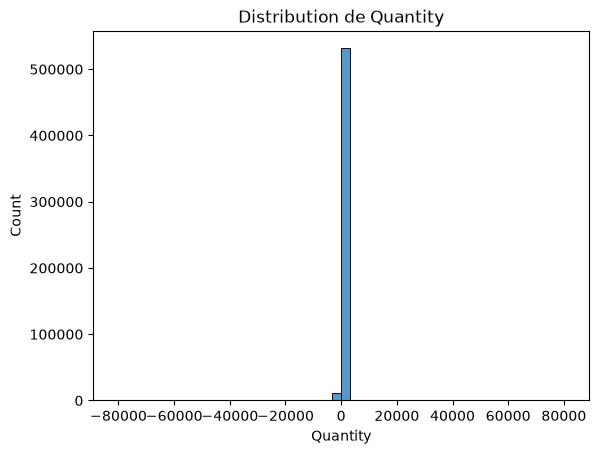

In [472]:
#distrucition de Quantity
sns.histplot(data=df, x="Quantity", bins=50)
plt.title("Distribution de Quantity")
plt.show()

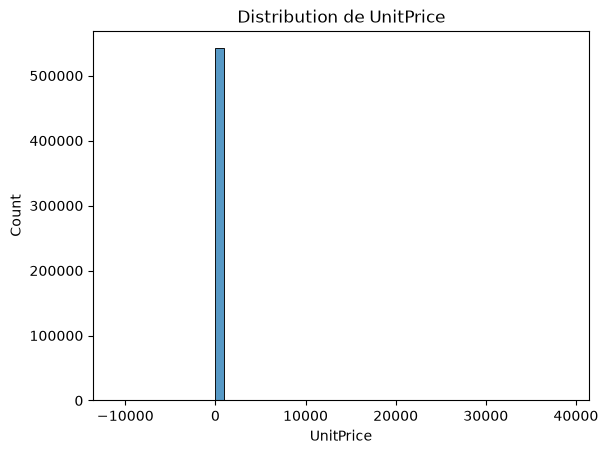

In [473]:
#distribution de unitPrice
sns.histplot(data=df, x="UnitPrice", bins=50)
plt.title("Distribution de UnitPrice")
plt.show()

Outliers

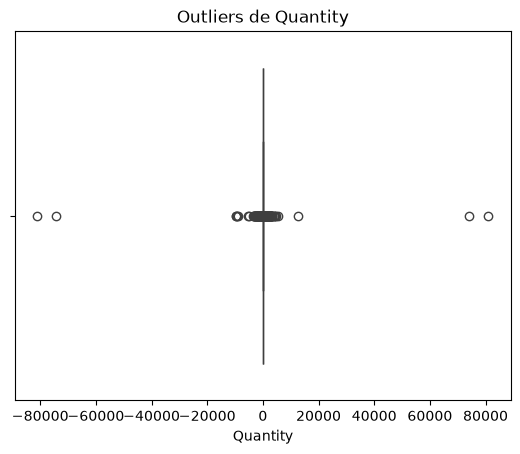

In [474]:
sns.boxplot(data=df, x="Quantity")
plt.title("Outliers de Quantity")
plt.show()

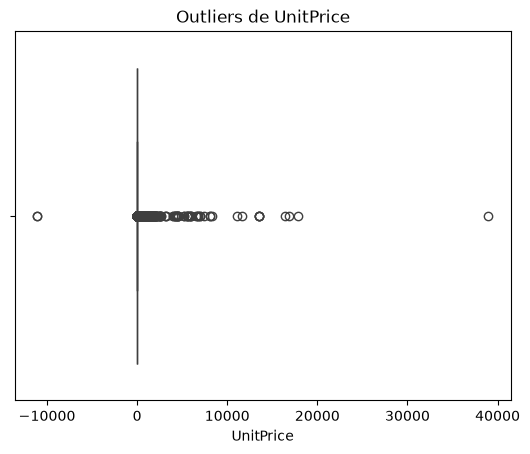

In [475]:
sns.boxplot(data=df, x="UnitPrice")
plt.title("Outliers de UnitPrice")
plt.show()

### Nettoyage et préparation des données

Gestion des valeurs manquantes

In [476]:
#copy data to work in 
df_clean=df.copy()

In [477]:
df_clean.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [478]:
#drop rows has now coustumerID
df_clean = df_clean.dropna(subset=["CustomerID"])

Gestion des doublons

In [479]:
# Compter les lignes complètement dupliquées (5225)
print("Nombre de doublons :", df_clean.duplicated().sum())

Nombre de doublons : 5225


In [480]:
#delete les rows qui sont identique 
df_clean = df_clean.drop_duplicates()

In [481]:
print("Doubons dans data initiale :",df.duplicated().sum())
print("Doublons restants :", df_clean.duplicated().sum())

Doubons dans data initiale : 5268
Doublons restants : 0


Gestion des valeurs invalides (Returns / cancellations)

In [482]:
#affiche price négatif or null 
df_clean[df_clean["UnitPrice"] <=0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560.0,United Kingdom
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911.0,EIRE
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,2011-01-13 15:10:00,0.0,15107.0,United Kingdom
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,0.0,17560.0,United Kingdom
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,2011-03-23 10:25:00,0.0,13239.0,United Kingdom
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,2011-03-30 12:45:00,0.0,13113.0,United Kingdom
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,2011-04-04 14:42:00,0.0,14410.0,United Kingdom


In [483]:
#affiche Quantity négatif or null 
df_clean[df_clean["Quantity"] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [484]:
#affiche nombre de InvoiceNo start with C
Cancellation = df_clean[
    df_clean["InvoiceNo"].astype(str).str.startswith("C")
]

print("Nombre de Cancellation :", len(Cancellation))

Nombre de Cancellation : 8872


In [485]:
Cancellation.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [486]:
Cancellation["Quantity"].describe()

#Conclusion : QUantity négative have relation with Cancellation donc quantité négatif is return 

count     8872.000000
mean       -30.774910
std       1172.249902
min     -80995.000000
25%         -6.000000
50%         -2.000000
75%         -1.000000
max         -1.000000
Name: Quantity, dtype: float64

In [487]:
# Supprimer les transactions annulées / retours
df_clean = df_clean[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C")
]

In [488]:
print("Quantity négative restante :", (df_clean["Quantity"] < 0).sum())

Quantity négative restante : 0


In [489]:
print("nbr UnitPrice  négative ou null  :", (df_clean["UnitPrice"] <= 0).sum())

nbr UnitPrice  négative ou null  : 40


#### Conversion des types

InvoiceDate

In [490]:
#transform type InvoiceDate to datetime
df_clean["InvoiceDate"] = pd.to_datetime(
    df_clean["InvoiceDate"],
    errors="coerce"
)

In [491]:
print(df_clean["InvoiceDate"].dtype)

datetime64[us]


In [492]:
df_clean["InvoiceDate"].dtype

dtype('<M8[us]')

CustomerID

In [493]:
#transform ID  to int 
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int)

Feature Engineering (Create new Columns TotalAmount)

In [494]:
df_clean["TotalAmount"] = (
    df_clean["Quantity"] * df_clean["UnitPrice"]
)

In [495]:
#drop columns we dont need in our logic
df_clean = df_clean.drop(
    columns=["Description", "StockCode", "Country"]
)

In [496]:
print(df_clean.columns)

Index(['InvoiceNo', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID',
       'TotalAmount'],
      dtype='str')


# Vérification après nettoyage

In [497]:
#shape
df_clean.shape

(392732, 6)

In [498]:
#missing
df_clean.isnull().sum()

InvoiceNo      0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
TotalAmount    0
dtype: int64

In [499]:
#Quantity
df_clean["Quantity"].describe()

count    392732.000000
mean         13.153718
std         181.588420
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

In [500]:
#unitPrice
df_clean["UnitPrice"].describe()

count    392732.000000
mean          3.125596
std          22.240725
min           0.000000
25%           1.250000
50%           1.950000
75%           3.750000
max        8142.750000
Name: UnitPrice, dtype: float64

In [501]:
#date
print(df_clean["InvoiceDate"].min())
print(df_clean["InvoiceDate"].max())

2010-12-01 08:26:00
2011-12-09 12:50:00


In [502]:
#nmbr Customer
df_clean["CustomerID"].nunique()

4339

# RFM 

In [503]:
df_clean["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

In [504]:
reference_date = df_clean["InvoiceDate"].max()

Calcul de Recency

In [505]:
rfm = df_clean.groupby("CustomerID").agg(
    LastPurchase=("InvoiceDate", "max"),
)

In [506]:
# Calcul de Recency
rfm["Recency"] = (
    reference_date - rfm["LastPurchase"]
).dt.days

# Supprimer LastPurchase
rfm = rfm.drop(columns=["LastPurchase"])

rfm.head()

#Recency Petit = Client Achat récemment 

,Recency
CustomerID,
12346,325
12347,1
12348,74
12349,18
12350,309


Calcul de Frequency (nombre de transaction / chaque client)

In [507]:
frequency = df_clean.groupby("CustomerID")["InvoiceNo"].nunique()

In [508]:
rfm["Frequency"] = frequency

In [509]:
rfm.head(10)

,Recency,Frequency
CustomerID,,
12346,325,1
12347,1,7
12348,74,4
12349,18,1
12350,309,1
12352,35,8
12353,203,1
12354,231,1
12355,213,1


In [510]:
print(df_clean.shape)

(392732, 6)


Calcul de Monetary

In [511]:
df_clean["TotalAmount"] = (
    df_clean["Quantity"] * df_clean["UnitPrice"]
)

In [512]:
monetary = df_clean.groupby("CustomerID")["TotalAmount"].sum()

In [513]:
rfm["Monetary"] = monetary

In [514]:
rfm.head(10)

,Recency,Frequency,Monetary
CustomerID,,,
12346,325,1,77183.60
12347,1,7,4310.00
12348,74,4,1797.24
12349,18,1,1757.55
12350,309,1,334.40
12352,35,8,2506.04
12353,203,1,89.00
12354,231,1,1079.40
12355,213,1,459.40


In [515]:
print(rfm.columns)

Index(['Recency', 'Frequency', 'Monetary'], dtype='str')


Analyse distributions des variables RFM 

In [516]:
#vérifier statistique
rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000
mean,91.518322,4.271952,2048.215924
std,100.009747,7.705493,8984.248352
min,0.000000,1.000000,0.000000
25%,17.000000,1.000000,306.455000
50%,50.000000,2.000000,668.560000
75%,141.000000,5.000000,1660.315000
max,373.000000,210.000000,280206.020000


##### Visualiser les distributions

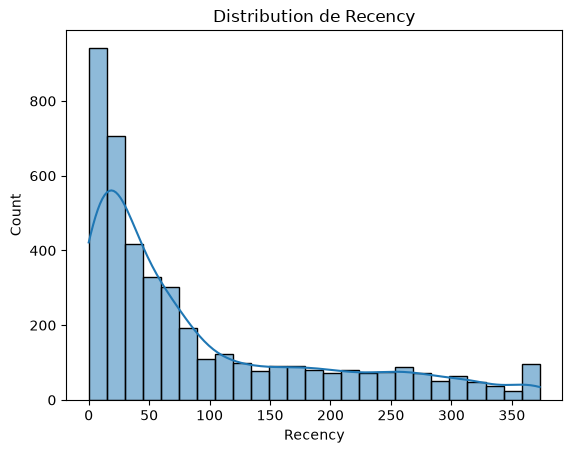

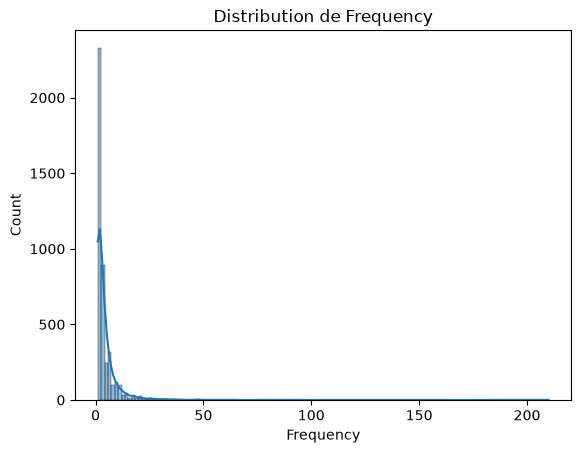

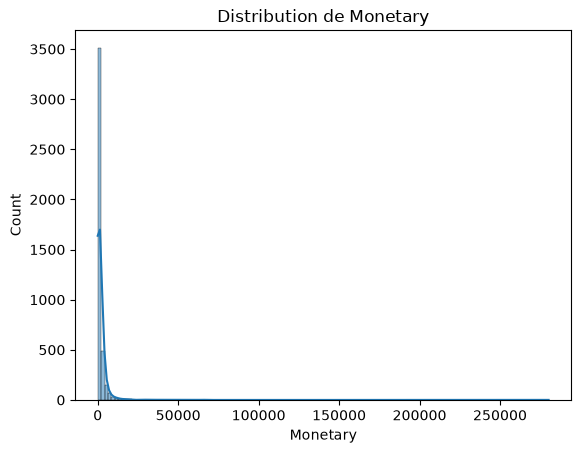

In [517]:
import matplotlib.pyplot as plt
import seaborn as sns

liste = ["Recency", "Frequency", "Monetary"]

for variable in liste:
    sns.histplot(rfm[variable], kde=True)
    plt.title(f"Distribution de {variable}")
    plt.show()

##### Calcul moyenne et médiane 

In [518]:
rfm[["Recency", "Frequency", "Monetary"]].agg(
    ["mean", "median", "std", "min", "max"]
)

,Recency,Frequency,Monetary
mean,91.518322,4.271952,2048.215924
median,50.000000,2.000000,668.560000
std,100.009747,7.705493,8984.248352
min,0.000000,1.000000,0.000000
max,373.000000,210.000000,280206.020000


In [519]:
#Vérfier skewness 
rfm[["Recency", "Frequency", "Monetary"]].skew()

#Frequency and Monetory has clients with values very big 

Recency       1.246357
Frequency    12.100028
Monetary     19.341403
dtype: float64

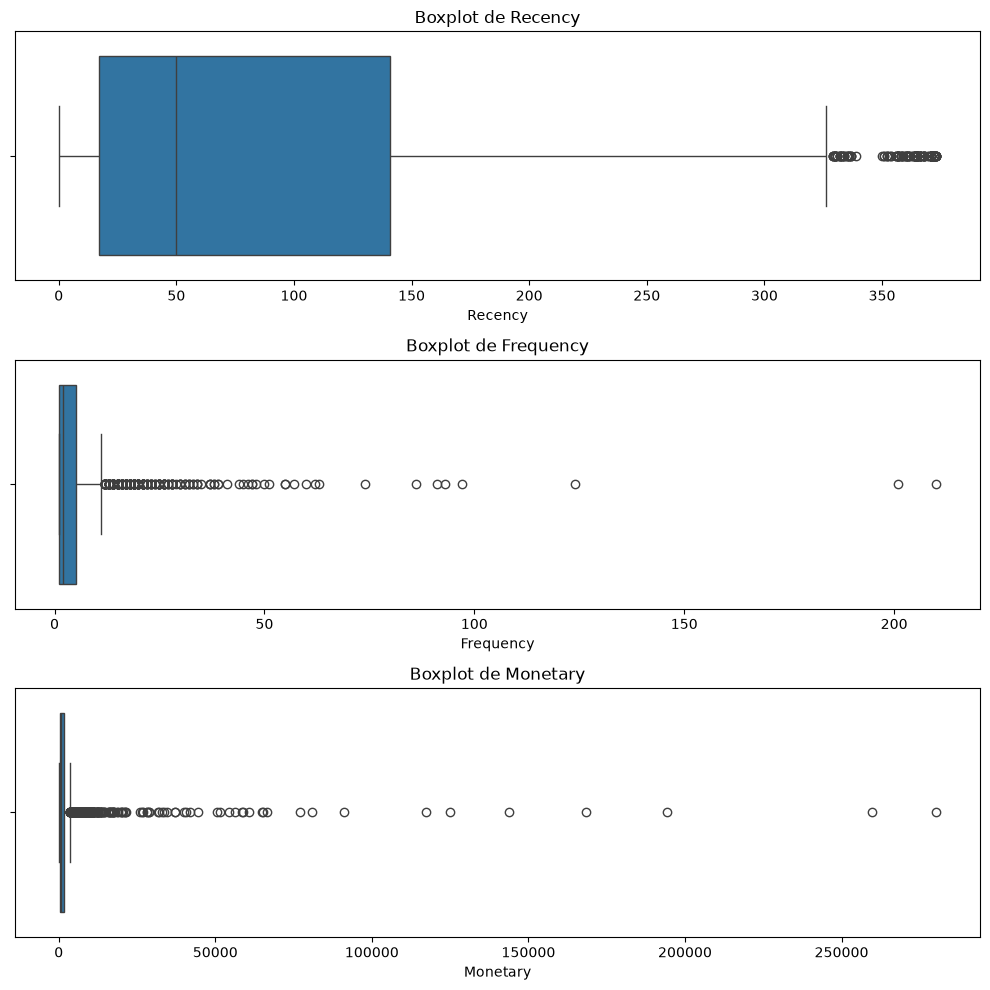

In [520]:
#visualiser les outliers 
fig, axes = plt.subplots(3, 1, figsize=(10, 10))

sns.boxplot(x=rfm["Recency"], ax=axes[0])
axes[0].set_title("Boxplot de Recency")

sns.boxplot(x=rfm["Frequency"], ax=axes[1])
axes[1].set_title("Boxplot de Frequency")

sns.boxplot(x=rfm["Monetary"], ax=axes[2])
axes[2].set_title("Boxplot de Monetary")

plt.tight_layout()
plt.show()

#### transformation logarithmique 

In [521]:
rfm_log = rfm[["Recency", "Frequency", "Monetary"]].copy()

In [522]:
rfm.skew()

Recency       1.246357
Frequency    12.100028
Monetary     19.341403
dtype: float64

In [523]:
rfm_log = np.log1p(rfm_log)

In [524]:
rfm_log.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,5.786897,0.693147,11.253955
12347,0.693147,2.079442,8.368925
12348,4.317488,1.609438,7.494564
12349,2.944439,0.693147,7.472245
12350,5.736572,0.693147,5.815324


In [525]:
rfm_log.skew()

#Recency: asymétrie à gauche 
#Frequency :Forte asymétrie à droite
#Monetory :Asymétrie à droite

Recency     -0.554079
Frequency    1.208917
Monetary     0.363728
dtype: float64

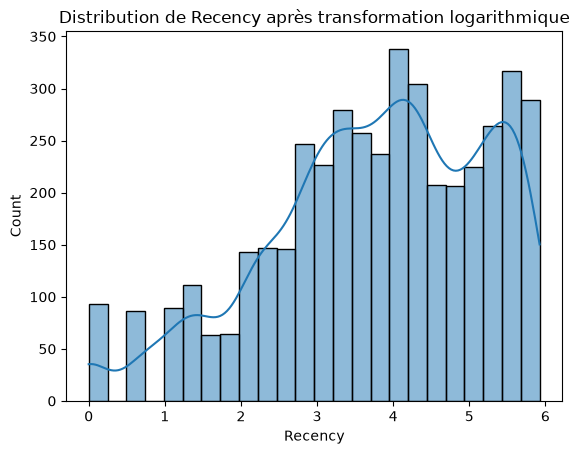

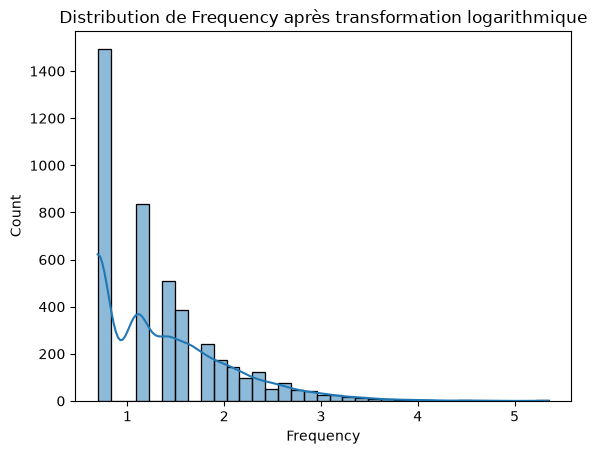

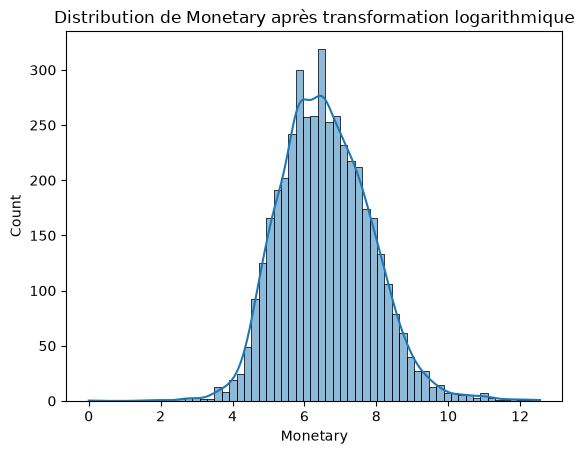

In [526]:
for column in rfm_log.columns:
    sns.histplot(rfm_log[column], kde=True)
    plt.title(f"Distribution de {column} après transformation logarithmique")
    plt.show()

#### Standarisation 

In [527]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

In [528]:
rfm_scaled = pd.DataFrame(rfm_scaled,columns=["Recency", "Frequency", "Monetary"],index=rfm.index)
print(rfm_scaled.head())

             Recency  Frequency  Monetary
CustomerID                               
12346       1.410138  -0.955013  3.697687
12347      -2.146411   1.074523  1.411820
12348       0.384170   0.386437  0.719046
12349      -0.574518  -0.955013  0.701362
12350       1.375000  -0.955013 -0.611449


In [529]:
#moyenne
rfm_scaled.mean()

Recency     -1.981463e-16
Frequency    1.965087e-17
Monetary    -2.554613e-16
dtype: float64

In [530]:
#écart type 
rfm_scaled.std()

Recency      1.000115
Frequency    1.000115
Monetary     1.000115
dtype: float64

#### Segementation avec K-Means 

In [531]:
from sklearn.cluster import KMeans

k_values = range(2, 10)

In [532]:
# Calcule d'inerti
inertias = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)

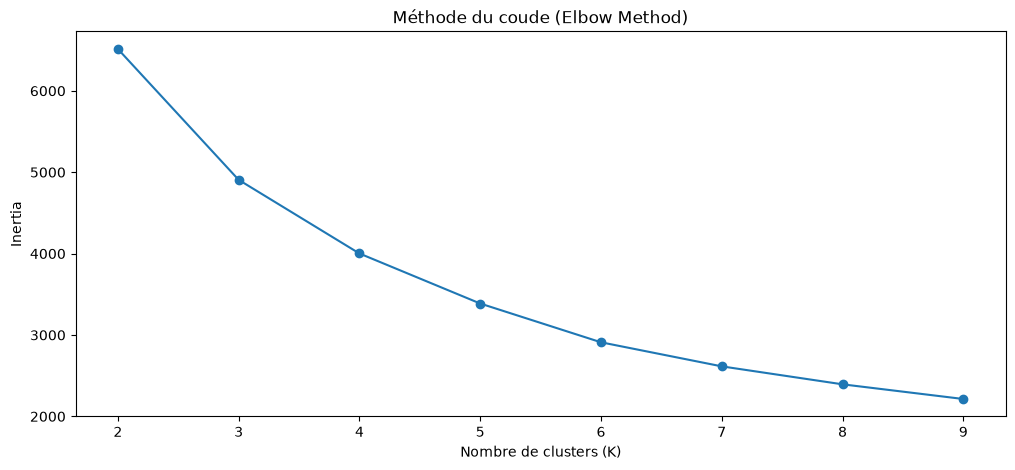

In [533]:
plt.figure(figsize=(12, 5))

plt.plot(k_values, inertias, marker="o")

plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Inertia")
plt.title("Méthode du coude (Elbow Method)")

plt.show()

#### Silhouette Score 

In [534]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

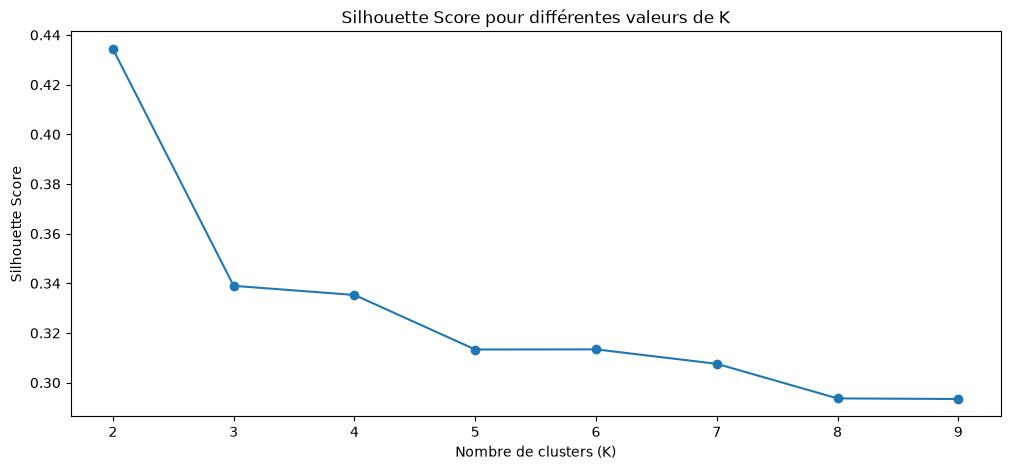

In [535]:
plt.figure(figsize=(12, 5))

plt.plot(k_values, silhouette_scores, marker="o")

plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score pour différentes valeurs de K")

plt.show()

#### Choisir K=3 

In [536]:
#entrainé K_means avec k=3
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=3,random_state=42,n_init=10)
rfm["Cluster"]=kmeans.fit_predict(rfm_scaled)

In [537]:
#combien de custmer dans chaque cluster 
rfm["Cluster"].value_counts().sort_index()

Cluster
0     729
1    1922
2    1688
Name: count, dtype: int64

#### Analyse les groupes obtenus 

#### Calcule CA

In [ ]:
profile = rfm.groupby("Cluster").agg(
    Nb_Clients=("Recency", "count"),
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean")
)

profile["CA_Total"] = rfm.groupby("Cluster")["Monetary"].sum()

profile["CA_%"] = profile["CA_Total"] / profile["CA_Total"].sum() * 100

profile

,Nb_Clients,Recency,Frequency,Monetary,CA_Total,CA_%
Cluster,,,,,,
0,729,12.932785,13.673525,8016.791358,5844240.900,65.760139
1,1922,161.136316,1.340271,352.000791,676545.521,7.612576
2,1688,46.188389,3.549763,1401.909048,2366422.473,26.627285
